# 실험 1.

### 온라인 pallet loading 환경의 최소 버전(MVP) 생성

In [1]:
import random
import math
import time
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict

import numpy as np
import pandas as pd

In [2]:
# -----------------------------
# Global Config 전역 설정 
# -----------------------------

# 파레트의 물리적 크기 정의 
PALLET_WIDTH = 110
PALLET_DEPTH = 110
PALLET_HEIGHT = 200 # 최대 높이 제한
PALLET_MAX_WEIGHT = 1500.0 # 최대 적재 무게 

# 운영할 파레트 개수 및 목적지 정보
NUM_PALLETS = 4
PALLET_REGIONS = ["A", "A", "B", "B"]

# 적재 물리 규칙 
SUPPORT_THRESHOLD = 0.7   # 물건을 쌓을 때 최소 70%가 밑의 물건이나 바닥에 닿아 있어야 함.
ALLOW_ROTATION = True # 물건을 가로/세로 돌려서 배치하는 것을 허용 

# 작업 데이터 규모
NUM_ITEMS = 300 # 총 물건의 개수 
QUEUE_LOOKAHEAD = 5 # 현재 물건을 쌓을 때, 다음에 올 물건 5개를 미리 확인해서 최적의 위치를 계산하는 코드

# 실험 재현성 설정 
SEED = 42 # 코드를 다시 실행해도 같은 결과가 나오도록 난수 설정 
random.seed(SEED)
np.random.seed(SEED)

In [3]:
### 데이터 구조 정의 
# -----------------------------
# 1. Item: 쌓아야 할 물건의 원본 정보
# -----------------------------
@dataclass
class Item:
    item_id: int # 물건 고유 번호
    w: int # 가로
    d: int # 세로
    h: int # 높이
    weight: float # 무게 
    region: str # 배송 지역(A or B) 
    load_bearing: float = 9999.0  # 적재 하중 (위에 얼마나 무거운 걸 올릴 수 있는지)
    # 수정해야 함. 랜덤 값 지정 

# -----------------------------
# 2. Placement: 물건이 놓일 3차원 좌표와 상태
# -----------------------------
@dataclass
class Placement:
    x: int # 가로 좌표
    y: int # 세로 좌표
    z: int # 높이 좌표(바닥이면 0)
    rotated: bool = True # 가로/세로 회전 여부 (True면 90도 회전)

# -----------------------------
# 3. PackedItem: '물건'이 특정 '위치'에 배치된 최종 결과물
# -----------------------------
@dataclass
class PackedItem:
    item: Item
    placement: Placement

    # 회전을 고려한 실질적인 크기 계산 
    @property
    def w(self): # 회전되었다면 원본의 깊이(d)를 가로(w)로 사용, 아니면 그대로 w 사용 
        return self.item.d if self.placement.rotated else self.item.w

    @property
    def d(self): # 회전되었다면 원본의 가로(w)를 깊이(d)로 사용, 아니면 그대로 d 사용
        return self.item.w if self.placement.rotated else self.item.d

    @property
    def h(self): # 높이는 회전해도 변하지 않음
        return self.item.h

# --- 3차원 공간상의 시작점(1)과 끝점(2) 좌표 ---
# 박스의 범위를 (x1, y1, z1) ~ (x2, y2, z2)로 정의함
    @property
    def x1(self):
        return self.placement.x

    @property
    def y1(self):
        return self.placement.y

    @property
    def z1(self):
        return self.placement.z

    @property
    def x2(self): # 시작점 + (회전 반영된) 가로 길이
        return self.x1 + self.w

    @property
    def y2(self): # 시작점 + (회전 반영된) 세로 길이
        return self.y1 + self.d

    @property
    def z2(self): # 시작점 + 높이
        return self.z1 + self.h

In [4]:
## 기하학적 겹침 계산 

# -----------------------------
# 1. overlap_1d: 선분끼리 얼마나 겹치는지 계산
# -----------------------------
def overlap_1d(a1, a2, b1, b2): # X축이나 Y축 하나만 놓고 봤을 때, 두 물건이 겹치는 길이를 구합니다
    return max(0, min(a2, b2) - max(a1, b1))

# -----------------------------
# 2. overlap_area_xy: 평면(바닥)에서 겹치는 면적 계산
# -----------------------------
def overlap_area_xy(ax1, ax2, ay1, ay2, bx1, bx2, by1, by2): 
    # 물건 A와 B를 위에서 내려다봤을 때, 서로 겹치는 사각형의 넓이를 구합니다.
    ox = overlap_1d(ax1, ax2, bx1, bx2) # X축으로 겹치는 길이(가로 겹침)
    oy = overlap_1d(ay1, ay2, by1, by2) # Y축으로 겹치는 길이(세로 겹침)
    return ox * oy # 겹침 면적 

In [5]:
# 파레트 상태 관리자 

class Pallet:
    def __init__(self, pallet_id: int, region: str,
                 W: int = PALLET_WIDTH, D: int = PALLET_DEPTH, H: int = PALLET_HEIGHT,
                 max_weight: float = PALLET_MAX_WEIGHT):
        # 파렛트 처음 만들 때 설정하는 값들 
        self.pallet_id = pallet_id # 파레트 번호
        self.region = region # 파레트가 갈 구역 
        self.W = W # 가로 너비 제한 
        self.D = D # 세로 깊이 제한 
        self.H = H # 높이 제한 
        self.max_weight = max_weight # 버틸 수 있는 최대 무게 
        self.items: List[PackedItem] = [] # 파레트에 담긴 물건 리스트

    def reset(self): # 새로운 시뮬레이션을 할 때 사용 
        self.items = []

    # 실시간 상태 계산 
    @property
    def total_weight(self): # 현재 파레트에 실린 물건들의 총 무게 합산 
        return sum(p.item.weight for p in self.items)

    @property
    def used_volume(self): # 현재 물건들이 차지하고 있는 순수 부피 합산 
        return sum(p.w * p.d * p.h for p in self.items)

    @property
    def total_volume(self): # 파렛트가 허용하는 전체 가용 부피 
        return self.W * self.D * self.H

    @property
    def fill_rate(self): # 부피 기준 적재율(얼마나 꽉 찼는지, 0.0~1.0 사이 값)
        return self.used_volume / self.total_volume if self.total_volume > 0 else 0.0

    @property
    def max_height(self): # 현재 쌓인 물건들 중 가장 높은 곳의 위치 (바닥부터의 높이 )
        if not self.items:
            return 0
        return max(p.z2 for p in self.items)

    def summary(self): # 현재 파레트의 상태를 한눈에 보기 좋게 사전 형태로 요약.
        return {
            "pallet_id": self.pallet_id,
            "region": self.region,
            "n_items": len(self.items),
            "fill_rate": round(self.fill_rate, 4),
            "max_height": self.max_height,
            "total_weight": round(self.total_weight, 2),
        }

In [6]:
# 경계선 체크 로직 

def in_bounds(pallet: Pallet, item: Item, placement: Placement):
    # 물건을 특정 위치에 놓았을 때, 파렛트의 물리적 크기 제한을 넘지 않는지 확인. 
    
    # 회전 여부에 따른 실제 가로와 세로 계산
    # 앞서 정의한 PackedItem의 로직과 동일하게, 회전 시 w와 d를 서로 바꿈. 
    w = item.d if placement.rotated else item.w
    d = item.w if placement.rotated else item.d
    h = item.h

# 2. 음수 좌표 체크 (좌표가 마이너스면 잘못된 위치)
    if placement.x < 0 or placement.y < 0 or placement.z < 0:
        return False

    # 3. X축(가로) 범위 체크
    # 시작점(x) + 물건 너비(w)가 파렛트 전체 너비(pallet.W)보다 크면 False
    if placement.x + w > pallet.W:
        return False

    # 4. Y축(세로/깊이) 범위 체크
    # 시작점(y) + 물건 깊이(d)가 파렛트 전체 깊이(pallet.D)보다 크면 False
    if placement.y + d > pallet.D:
        return False

    # 5. Z축(높이) 범위 체크
    # 시작점(z) + 물건 높이(h)가 파렛트 최대 높이(pallet.H)보다 크면 False
    if placement.z + h > pallet.H:
        return False

    # 모든 조건을 통과하면 안전하게 파렛트 안에 들어온다는 뜻입니다.
    return True

In [7]:
def collides_with_any(pallet: Pallet, item: Item, placement: Placement):
    """
    새로 놓으려는 물건(item)이 파렛트에 이미 배치된 
    어떤 물건(p)과도 3차원 공간에서 겹치지 않는지 검사합니다.
    """
    # 1. 회전을 고려한 새 물건의 실질적 크기 계산
    test_w = item.d if placement.rotated else item.w
    test_d = item.w if placement.rotated else item.d
    test_h = item.h

    # 2. 새 물건의 3D 시작점(1)과 끝점(2) 좌표 설정
    tx1, ty1, tz1 = placement.x, placement.y, placement.z
    tx2, ty2, tz2 = tx1 + test_w, ty1 + test_d, tz1 + test_h

    # 3. 파렛트에 이미 들어있는 모든 물건(p)을 하나씩 꺼내어 비교
    for p in pallet.items:
        # 이전에 정의한 overlap_1d 함수를 사용하여 X, Y, Z 각 축의 겹침 길이를 구함
        ox = overlap_1d(tx1, tx2, p.x1, p.x2) # 가로 겹침
        oy = overlap_1d(ty1, ty2, p.y1, p.y2) # 세로 겹침
        oz = overlap_1d(tz1, tz2, p.z1, p.z2) # 높이 겹침

        # 4. 판정: 모든 축(X, Y, Z)에서 겹침이 0보다 크면 '충돌'임
        # 하나라도 0이면 그 방향으로는 떨어져 있다는 뜻이므로 충돌이 아님
        if ox > 0 and oy > 0 and oz > 0:
            return True  # 충돌 발생!
            
    # 모든 물건과 비교했을 때 3축 동시 겹침이 없다면 안전함
    return False

In [8]:
# 적재 높이 결정 함수 분석

def get_support_z(pallet: Pallet, item: Item, x: int, y: int, rotated: bool):
    """
    특정 위치(x, y)에 물건을 놓으려고 할 때, 
    아래에서 받쳐줄 수 있는 가장 높은 높이(z)를 계산합니다.
    """
    # 1. 회전을 고려하여 놓으려는 물건의 실제 바닥 크기 계산
    w = item.d if rotated else item.w
    d = item.w if rotated else item.d

    # 2. 기본 높이는 바닥(0)으로 설정
    support_z = 0
    
    # 3. 파렛트에 이미 배치된 모든 물건(p)을 확인
    for p in pallet.items:
        # 내가 놓으려는 (x, y) 범위와 이미 놓인 물건 p의 (x, y) 범위가 겹치는지 확인
        overlap = overlap_area_xy(x, x + w, y, y + d, p.x1, p.x2, p.y1, p.y2)
        
        # 4. 만약 조금이라도 겹친다면 (즉, p가 내 밑에 부분적으로라도 있다면)
        if overlap > 0:
            # 그 물건의 윗면 높이(p.z2)와 현재까지 찾은 최고 높이를 비교해서 업데이트
            # 이를 통해 '내 바로 아래에 있는 여러 물건 중 가장 높은 놈' 위에 놓이게 됨
            support_z = max(support_z, p.z2)
            
    # 최종적으로 결정된 높이를 반환
    return support_z

In [9]:
# 지지율 계산 함수 분석 

def compute_support_ratio(pallet: Pallet, item: Item, placement: Placement):
    """
    물건을 특정 위치에 놓았을 때, 아래에 있는 물건들이 
    이 물건의 바닥면을 얼마나(몇 %) 받쳐주고 있는지 계산합니다.
    """
    # 1. 회전을 고려한 현재 물건의 바닥 면적(Base Area) 계산
    w = item.d if placement.rotated else item.w
    d = item.w if placement.rotated else item.d
    base_area = w * d

    # 2. 바닥(z=0)에 놓는 경우
    # 파렛트 바닥은 전체가 단단하므로 무조건 100%(1.0) 지지됨으로 간주
    if placement.z == 0:
        return 1.0

    # 3. 공중에 놓는 경우 (z > 0)
    supported_area = 0  # 받쳐지고 있는 면적의 합계
    
    for p in pallet.items:
        # 내 바닥(placement.z)과 아래 물건의 윗면(p.z2)이 딱 맞닿아 있는지 확인
        if p.z2 == placement.z:
            # 맞닿아 있다면, 두 물건이 X-Y 평면에서 얼마나 겹치는지 면적을 구해서 더함
            supported_area += overlap_area_xy(
                placement.x, placement.x + w,
                placement.y, placement.y + d,
                p.x1, p.x2,
                p.y1, p.y2
            )

    # 4. (실제 받쳐주는 면적 / 전체 바닥 면적) 비율 반환
    return supported_area / base_area if base_area > 0 else 0.0

In [10]:
# 적재 하중 검사 함수

def check_load_bearing_simple(pallet: Pallet, item: Item, placement: Placement):
    """
    새로 놓으려는 물건(item)의 무게를 아래에 있는 물건들(supporters)이 
    안전하게 버틸 수 있는지 확인합니다.
    """
    # 1. 바닥(z=0)에 놓는 경우
    # 파렛트 바닥은 이론상 무한한 하중을 견디므로 항상 True
    if placement.z == 0:
        return True

    supporters = [] # 나를 받쳐주고 있는 아래 물건들의 리스트
    w = item.d if placement.rotated else item.w
    d = item.w if placement.rotated else item.d

    # 2. 내 바로 밑에서 나를 지탱하는 물건(supporters) 찾기
    for p in pallet.items:
        # 내 바닥(placement.z)과 아래 물건의 윗면(p.z2)이 맞닿아 있는지 확인
        if p.z2 == placement.z:
            # 면적이 겹친다면 나를 지탱하는 후보임
            overlap = overlap_area_xy(
                placement.x, placement.x + w,
                placement.y, placement.y + d,
                p.x1, p.x2,
                p.y1, p.y2
            )
            if overlap > 0:
                supporters.append(p)

    # 3. 받쳐주는 물건이 아예 없으면 (공중 부양 상태) 실패
    if not supporters:
        return False

    # 4. 하중 분산 계산 (매우 단순화된 모델)
    # 내 무게(item.weight)를 나를 받치는 물건의 개수만큼 똑같이 나눕니다.
    distributed_weight = item.weight / len(supporters)
    
    # 5. 한계치 검사
    for s in supporters:
        # 분산된 무게가 아래 물건(s)이 버틸 수 있는 한계(load_bearing)를 넘으면 False
        # 예: 계란판 위에 무거운 아령을 올리는 상황을 방지함
        if distributed_weight > s.item.load_bearing:
            return False

    # 모든 지지 물건이 내 무게를 견딜 수 있다면 True
    return True

In [11]:
# 적재 가능 여부 최종 승인 함수 

def is_valid_placement(pallet: Pallet, item: Item, placement: Placement,
                       support_threshold: float = SUPPORT_THRESHOLD):
    """
    물건을 이 파렛트의 이 위치에 놓아도 되는지 '모든' 조건을 검사합니다.
    """
    
    # 1. 구역 일치 여부 (Region Check)
    # A구역으로 갈 물건이 B구역 파렛트에 실리면 안 되겠죠?
    if item.region != pallet.region:
        return False

    # 2. 파렛트 무게 제한 (Weight Limit)
    # 현재 실린 무게 + 새 물건 무게가 파렛트의 최대 적재 중량을 넘는지 확인합니다.
    if pallet.total_weight + item.weight > pallet.max_weight:
        return False

    # 3. 파렛트 경계 내부 (In-Bounds Check)
    # 물건이 파렛트 밖으로 튀어나오지 않는지 확인합니다.
    if not in_bounds(pallet, item, placement):
        return False

    # 4. 물리적 충돌 (Collision Check)
    # 이미 놓인 다른 물건들과 3D 공간상에서 겹치는지 확인합니다.
    if collides_with_any(pallet, item, placement):
        return False

    # 5. 적재 안정성 (Stability/Support Check)
    # 아래 물건들이 내 바닥을 충분히(예: 70% 이상) 받쳐주고 있는지 확인합니다.
    support_ratio = compute_support_ratio(pallet, item, placement)
    if support_ratio < support_threshold:
        return False

    # 6. 하중 견딤 (Load-Bearing Check)
    # 내 아래에 깔린 상자들이 내 무게를 버틸 수 있는지 확인합니다.
    if not check_load_bearing_simple(pallet, item, placement):
        return False

    # 위 모든 관문을 통과하면 배치 가능!
    return True

In [12]:
### 후보 좌표 생성 로직

def generate_candidate_xy(pallet: Pallet):
    """
    파렛트 바닥면(X-Y 평면)에서 물건을 놓을 수 있는 
    '의미 있는' 후보 좌표들의 리스트를 만듭니다.
    """
    # 1. 초기값 설정: 가장 기본인 왼쪽 구석 (0, 0)
    xs = {0}
    ys = {0}

    # 2. 기존 물건들의 경계선을 후보로 추가
    # 이미 놓인 물건들의 시작점(x1, y1)과 끝점(x2, y2)을 후보군에 넣습니다.
    # 이렇게 하면 물건들을 서로 빈틈없이 바짝 붙여서(Tightly) 쌓을 수 있습니다.
    for p in pallet.items:
        xs.add(p.x2) # 기존 물건의 오른쪽 끝
        ys.add(p.y2) # 기존 물건의 위쪽 끝
        xs.add(p.x1) # 기존 물건의 왼쪽 시작
        ys.add(p.y1) # 기존 물건의 아래쪽 시작

    # 3. 유효한 범위로 필터링 및 정렬
    # 파렛트 크기(W, D)를 벗어나지 않는 좌표들만 추리고, 
    # 왼쪽/아래부터 탐색하기 위해 오름차순으로 정렬합니다.
    xs = sorted(x for x in xs if 0 <= x < pallet.W)
    ys = sorted(y for y in ys if 0 <= y < pallet.D)

    # 4. 모든 X와 Y 조합을 엮어서 (x, y) 좌표 쌍 생성
    candidates = []
    for x in xs:
        for y in ys:
            candidates.append((x, y))
            
    return candidates

### 휴리스틱 함수 정의

Bottom-Up 전략 (placement.z): 가장 낮은 곳부터 채우기 때문에 파렛트가 위아래로 흔들리지 않고 안정적으로 쌓입니다.

Corner-Fill 전략 (x + y): 물건을 구석으로 몰아서 배치하므로, 나중에 큰 물건이 들어올 수 있도록 커다란 연속 빈 공간을 남겨두는 효과가 있습니다.

철저한 검증: is_valid_placement를 통해 "좋아 보이는 자리"가 아니라 "실제로 가능한 자리"만 골라냅니다.

In [13]:
### 최적 적재 위치 탐색 함수

def find_heuristic_placement(pallet: Pallet, item: Item):
    """
    물건 하나를 파렛트 위의 가장 효율적인 자리에 배치하기 위해
    모든 후보지를 검사하고 점수를 매겨 최적의 장소를 반환합니다.
    """
    best = None        # 현재까지 찾은 가장 좋은 위치
    best_score = None  # 그 위치의 점수 (낮을수록 좋음)

    # 1. 회전 여부 결정
    # 회전이 허용되고, 가로/세로 길이가 다를 때만 '돌리기(True)' 옵션을 추가함
    rotations = [False, True] if ALLOW_ROTATION and item.w != item.d else [False]

    for rotated in rotations:
        # 2. 앞서 만든 generate_candidate_xy를 통해 후보 (x, y) 좌표를 하나씩 꺼냄
        for x, y in generate_candidate_xy(pallet):
            # 3. 해당 (x, y)에서 물건이 내려앉을 높이(z)를 계산
            z = get_support_z(pallet, item, x, y, rotated)
            placement = Placement(x=x, y=y, z=z, rotated=rotated)

            # 4. 모든 물리/비즈니스 규칙(경계, 충돌, 지지율 등)을 통과하는지 확인
            if is_valid_placement(pallet, item, placement):
                
                # 5. [핵심] 점수 매기기 (Heuristic Score)
                # 파이썬은 튜플끼리 비교할 때 앞의 요소부터 비교합니다.
                # (1순위) z: 높이가 가장 낮은 곳 (낮게 쌓기)
                # (2순위) x + y: 원점(0,0)에서 가장 가까운 곳 (밀착 쌓기)
                # (3, 4순위) x, y: 동점일 경우 왼쪽과 앞쪽 우선
                score = (placement.z, placement.x + placement.y, placement.x, placement.y)
                
                # 기존에 찾은 명당보다 더 점수가 낮다면(더 좋은 자리라면) 업데이트
                if best_score is None or score < best_score:
                    best = placement
                    best_score = score

    # 가장 좋은 위치 정보를 반환 (못 찾으면 None)
    return best

In [14]:
### 물건 배치 확정 함수

def place_item(pallet: Pallet, item: Item, placement: Placement):
    """
    검증이 끝난 물건을 파렛트의 특정 위치에 실제로 '적재'합니다.
    """
    # 1. PackedItem 객체 생성
    # 원본 물건 정보(item)와 결정된 위치/회전 정보(placement)를 하나로 묶습니다.
    # 이때 PackedItem 내부의 @property 로직에 의해 
    # x2, y2, z2(끝점) 좌표 등이 자동으로 계산됩니다.
    packed = PackedItem(item=item, placement=placement)
    
    # 2. 파렛트 리스트에 추가
    # 파렛트(Pallet) 클래스의 items 리스트에 이 물건을 집어넣습니다.
    # 이제부터 이 물건은 다른 물건을 쌓을 때 '받침대'가 되거나 '충돌 대상'이 됩니다.
    pallet.items.append(packed)

In [15]:
# -----------------------------
# 1. make_pallets: 파렛트 꾸러미 생성 함수
# -----------------------------
def make_pallets():
    """
    전역 설정값(NUM_PALLETS)에 따라 지정된 개수만큼 
    Pallet 객체를 생성하여 리스트로 반환합니다.
    """
    # 리스트 컴프리헨션을 사용하여 0번부터 (NUM_PALLETS-1)번까지 생성
    # 각 파렛트는 미리 정해진 구역(A 또는 B) 정보를 할당받습니다.
    return [Pallet(pallet_id=i, region=PALLET_REGIONS[i]) for i in range(NUM_PALLETS)]

# -----------------------------
# 2. 실행 및 확인
# -----------------------------
# 실제로 4개의 빈 파렛트를 만듭니다.
pallets = make_pallets()

# 생성된 모든 파렛트의 요약 정보(ID, 구역, 무게, 적재율 등)를 리스트로 출력합니다.
# 처음에는 아무것도 들어있지 않으므로 n_items: 0, fill_rate: 0.0 등이 나옵니다.
[p.summary() for p in pallets]

[{'pallet_id': 0,
  'region': 'A',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0},
 {'pallet_id': 1,
  'region': 'A',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0},
 {'pallet_id': 2,
  'region': 'B',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0},
 {'pallet_id': 3,
  'region': 'B',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0}]

In [16]:
# 가상 물건 생성기 

def generate_items(n=NUM_ITEMS):
    """
    설정된 개수(n)만큼 무작위 속성을 가진 물건(Item) 객체들을 생성합니다.
    """
    items = []
    for i in range(n):
        # 1. 크기 결정 (가로, 세로, 높이)
        # 10cm ~ 35cm 사이의 정수 값을 무작위로 선택
        w = random.randint(10, 35)
        d = random.randint(10, 35)
        h = random.randint(8, 30)
        
        # 2. 무게 결정
        # 2.0kg ~ 15.0kg 사이의 실수를 소수점 둘째 자리까지 생성
        weight = round(random.uniform(2.0, 15.0), 2)
        
        # 3. 배송 구역 결정
        # A구역 또는 B구역 중 하나를 무작위로 선택
        region = random.choice(["A", "B"])
        
        # 4. 적재 하중(Load Bearing) 결정
        # 이 박스가 위에 얼마나 견딜 수 있는지(10kg ~ 40kg) 무작위 설정
        # 아까 check_load_bearing_simple 함수에서 쓰였던 그 값입니다!
        load_bearing = round(random.uniform(10.0, 40.0), 2)
        
        # 5. 생성된 값을 Item 객체에 담아 리스트에 추가
        items.append(Item(
            item_id=i,
            w=w,
            d=d,
            h=h,
            weight=weight,
            region=region,
            load_bearing=load_bearing
        ))
    return items

# 실제로 10개의 물건을 생성하고, 그중 앞의 3개만 확인해봅니다.
items = generate_items(10)
items[:3]

[Item(item_id=0, w=30, d=13, h=8, weight=11.64, region='A', load_bearing=16.7),
 Item(item_id=1, w=33, d=13, h=29, weight=11.63, region='A', load_bearing=27.71),
 Item(item_id=2, w=11, d=10, h=10, weight=4.84, region='A', load_bearing=26.84)]

In [17]:
### 파레트 선택 규칙 함수 분석 

def select_pallet_rule_based(item: Item, pallets: List[Pallet]):
    """
    물건(item)의 구역 정보를 확인하고, 
    가장 적절한 파렛트(pallet)들을 우선순위에 따라 정렬하여 반환합니다.
    """
    
    # 1. 구역 필터링 (Region Match)
    # 물건의 배송지(A 또는 B)와 파렛트의 목적지가 일치하는 것들만 골라냅니다.
    # A구역 물건은 A구역 파렛트에만 가야 하니까요.
    valid_region_pallets = [p for p in pallets if p.region == item.region]

    # 2. 우선순위 정렬 (Sorting by Strategy)
    # 정렬 기준(key)을 설정하여 어떤 파렛트를 먼저 시도할지 정합니다.
    # (1순위) p.fill_rate: 현재 얼마나 차 있는지 (적재율)
    # (2순위) p.max_height: 현재 쌓인 높이
    # 기본적으로 오름차순(낮은 것부터) 정렬되지만, 상황에 따라 '가장 많이 찬 곳'부터 
    # 시도하도록 로직이 이어질 것입니다.
    valid_region_pallets = sorted(valid_region_pallets, key=lambda p: (p.fill_rate, p.max_height))

    return valid_region_pallets

### 단일 물건 생성 테스트

In [18]:
### 단일 물건 생성 테스트

# 1. 새 파렛트 세트 준비
# 4개의 빈 파렛트(A구역 2개, B구역 2개)를 새로 만듭니다.
pallets = make_pallets()

# 2. 딱 하나의 테스트용 물건 생성
# generate_items(1)은 리스트를 반환하므로, 그중 첫 번째 원소([0])를 꺼냅니다.
test_item = generate_items(1)[0]

# 3. 생성된 물건의 상세 정보 출력
# 이 줄이 실행되면 아래와 같은 속성들이 화면에 보일 것입니다.
# 예: Item(item_id=0, w=24, d=15, h=10, weight=5.5, region='A', load_bearing=25.3)
test_item

Item(item_id=0, w=17, d=13, h=20, weight=5.61, region='B', load_bearing=14.88)

In [19]:
# 첫 번째 물건 적재 시뮬레이션

# 1. 물건의 구역에 맞는 파렛트 후보군 추출
# A구역 물건이면 A구역 파렛트들만, B구역이면 B구역 파렛트들만 가져옵니다.
candidate_pallets = select_pallet_rule_based(test_item, pallets)

chosen = None # 실제로 배치가 성공했을 때의 정보를 담을 변수

# 2. 후보 파렛트들을 하나씩 순회하며 빈자리 찾기
for p in candidate_pallets:
    # 해당 파렛트에서 가장 좋은(Heuristic) 위치를 계산합니다.
    # (내부적으로 경계 체크, 충돌 체크, 지지율 체크가 모두 수행됨)
    placement = find_heuristic_placement(p, test_item)
    
    # 3. 만약 적절한 위치(Placement)가 발견되었다면?
    if placement is not None:
        # 실제로 그 파렛트에 물건을 확정해서 넣습니다.
        place_item(p, test_item, placement)
        
        # 어떤 파렛트의 어떤 좌표(x, y, z, rotated)에 넣었는지 기록하고 루프 종료
        chosen = (p.pallet_id, placement)
        break

# 최종 결과 출력 (예: (0, Placement(x=0, y=0, z=0, rotated=False)))
chosen

(2, Placement(x=0, y=0, z=0, rotated=False))

In [20]:
# 단일 물건 적재 테스트 파레트 상황 파악

[p.summary() for p in pallets]



[{'pallet_id': 0,
  'region': 'A',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0},
 {'pallet_id': 1,
  'region': 'A',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0},
 {'pallet_id': 2,
  'region': 'B',
  'n_items': 1,
  'fill_rate': 0.0018,
  'max_height': 20,
  'total_weight': 5.61},
 {'pallet_id': 3,
  'region': 'B',
  'n_items': 0,
  'fill_rate': 0.0,
  'max_height': 0,
  'total_weight': 0}]

### 시뮬레이션 실행기

In [21]:
def run_simulation(items: List[Item], verbose: bool = False):
    """
    물건 리스트를 받아 파렛트 적재 시뮬레이션을 수행하고 전체 결과를 리포트합니다.
    """
    pallets = make_pallets() # 깨끗한 새 파렛트들 준비
    logs = []                # 개별 물건의 적재 이력을 기록할 리스트
    placed_count = 0         # 적재에 성공한 물건 개수
    start_time = time.time() # 전체 실행 시간 측정을 위해 시작 시각 기록

    for item in items:
        decision_start = time.time() # 개별 물건 하나에 걸리는 계산 시간 측정
        placed = False
        chosen_pallet_id = None
        chosen_placement = None

        # 1. 물건 구역에 맞는 파렛트 후보들 선정
        candidate_pallets = select_pallet_rule_based(item, pallets)

        # 2. 후보 파렛트들을 돌며 자리가 있는지 탐색 (Heuristic Search)
        for pallet in candidate_pallets:
            placement = find_heuristic_placement(pallet, item)
            
            # 3. 빈자리를 찾았다면 즉시 적재 확정!
            if placement is not None:
                place_item(pallet, item, placement)
                placed = True
                chosen_pallet_id = pallet.pallet_id
                chosen_placement = placement
                placed_count += 1
                break # 자리를 찾았으므로 다음 파렛트는 볼 필요 없음

        decision_time = time.time() - decision_start

        # 4. 개별 물건의 운명을 로그로 기록
        logs.append({
            "item_id": item.item_id,
            "region": item.region,
            "placed": placed, # 적재 성공 여부
            "pallet_id": chosen_pallet_id,
            "x": None if chosen_placement is None else chosen_placement.x,
            "y": None if chosen_placement is None else chosen_placement.y,
            "z": None if chosen_placement is None else chosen_placement.z,
            "decision_time": decision_time, # 이 물건을 어디 놓을지 고민한 시간
        })

        if verbose: # 진행 상황 실시간 출력 모드
            print(f"Item {item.item_id} | region={item.region} | placed={placed} | pallet={chosen_pallet_id}")

    # 5. 전체 데이터 정리 및 통계 계산
    total_time = time.time() - start_time
    df = pd.DataFrame(logs) # 판다스 데이터프레임으로 변환하여 분석 용이하게 함

    result = {
        "placed_count": placed_count,           # 총 적재 성공 개수
        "arrival_count": len(items),
        "success_rate": placed_count / len(items), # 적재 성공률 (KPI)
        "avg_decision_time": df["decision_time"].mean(), # 평균 계산 속도
        "total_runtime": total_time,            # 전체 시뮬레이션 소요 시간
        "pallet_summaries": [p.summary() for p in pallets], # 파렛트별 최종 상태
        "logs": df,                             # 전체 이력 데이터프레임
        "pallets": pallets                      # 최종 적재된 파렛트 객체들
    }
    return result

### 적재 시뮬레이션 실행

In [22]:
##### 적재 시뮬레이션 실행

items = generate_items(NUM_ITEMS)
result = run_simulation(items, verbose=False)

result["placed_count"], result["arrival_count"], result["success_rate"]

(300, 300, 1.0)

In [23]:
# 결과 파악

pd.DataFrame(result["pallet_summaries"])
result["logs"].head()

print("Success rate:", round(result["success_rate"], 4))
print("Average decision time:", round(result["avg_decision_time"], 6), "sec")
print("Total runtime:", round(result["total_runtime"], 4), "sec")

Success rate: 1.0
Average decision time: 1.092181 sec
Total runtime: 327.6552 sec


In [24]:
summary_df = pd.DataFrame(result["pallet_summaries"])
summary_df[["pallet_id", "region", "n_items", "fill_rate", "max_height", "total_weight"]]

,pallet_id,region,n_items,fill_rate,max_height,total_weight
0,0,A,68,0.2956,103,566.74
1,1,A,67,0.2936,179,546.79
2,2,B,82,0.3194,130,706.31
3,3,B,83,0.3189,120,614.87


### 2차원 시각화

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_pallet_topview(pallet, figsize=(6, 5)):
    fig, ax = plt.subplots(figsize=figsize)

    # pallet outer boundary
    ax.add_patch(Rectangle((0, 0), pallet.W, pallet.D, fill=False, edgecolor='black', linewidth=2))

    for p in pallet.items:
        rect = Rectangle(
            (p.x1, p.y1),
            p.w,
            p.d,
            fill=True,
            alpha=0.5
        )
        ax.add_patch(rect)

        ax.text(
            p.x1 + p.w / 2,
            p.y1 + p.d / 2,
            f"id={p.item.item_id}\nz={p.z1}",
            ha='center',
            va='center',
            fontsize=8
        )

    ax.set_xlim(0, pallet.W)
    ax.set_ylim(0, pallet.D)
    ax.set_aspect('equal')
    ax.set_title(f"Pallet {pallet.pallet_id} (Region {pallet.region}) - Top View")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    plt.show()

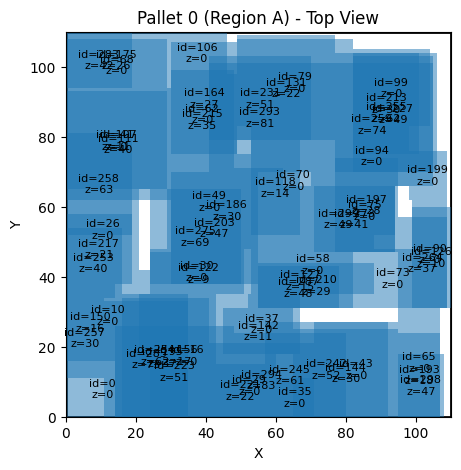

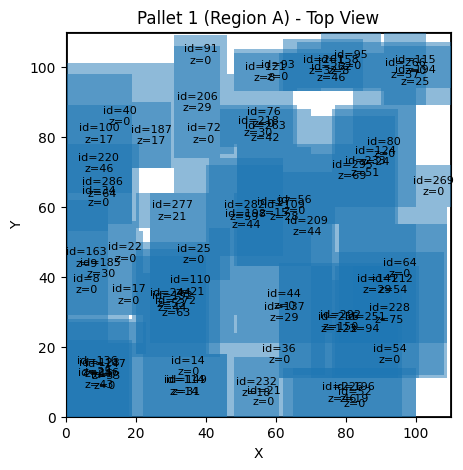

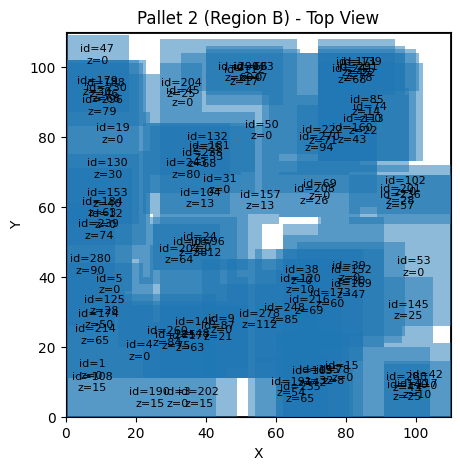

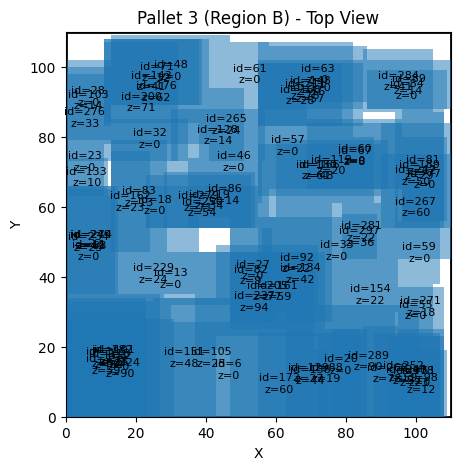

In [26]:
for pallet in result["pallets"]:
    plot_pallet_topview(pallet)

### 3차원 시각화

In [27]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt

def cuboid_faces(x, y, z, dx, dy, dz):
    # 8 vertices
    v = np.array([
        [x,     y,     z],
        [x+dx,  y,     z],
        [x+dx,  y+dy,  z],
        [x,     y+dy,  z],
        [x,     y,     z+dz],
        [x+dx,  y,     z+dz],
        [x+dx,  y+dy,  z+dz],
        [x,     y+dy,  z+dz]
    ])

    faces = [
        [v[0], v[1], v[2], v[3]],  # bottom
        [v[4], v[5], v[6], v[7]],  # top
        [v[0], v[1], v[5], v[4]],  # front
        [v[1], v[2], v[6], v[5]],  # right
        [v[2], v[3], v[7], v[6]],  # back
        [v[3], v[0], v[4], v[7]],  # left
    ]
    return faces

In [28]:
def plot_pallet_3d(pallet, figsize=(8, 6)):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    # pallet box outline
    pallet_faces = cuboid_faces(0, 0, 0, pallet.W, pallet.D, pallet.H)
    pallet_poly = Poly3DCollection(
        pallet_faces,
        facecolors='lightgrey',
        edgecolors='black',
        linewidths=0.3,
        alpha=0.05
    )
    ax.add_collection3d(pallet_poly)

    # items
    for p in pallet.items:
        faces = cuboid_faces(p.x1, p.y1, p.z1, p.w, p.d, p.h)
        poly = Poly3DCollection(
            faces,
            alpha=0.4,
            edgecolors='black',
            linewidths=0.5
        )
        ax.add_collection3d(poly)

        ax.text(
            p.x1 + p.w / 2,
            p.y1 + p.d / 2,
            p.z1 + p.h / 2,
            str(p.item.item_id),
            fontsize=8
        )

    ax.set_xlim(0, pallet.W)
    ax.set_ylim(0, pallet.D)
    ax.set_zlim(0, pallet.H)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"Pallet {pallet.pallet_id} (Region {pallet.region}) - 3D View")

    plt.show()

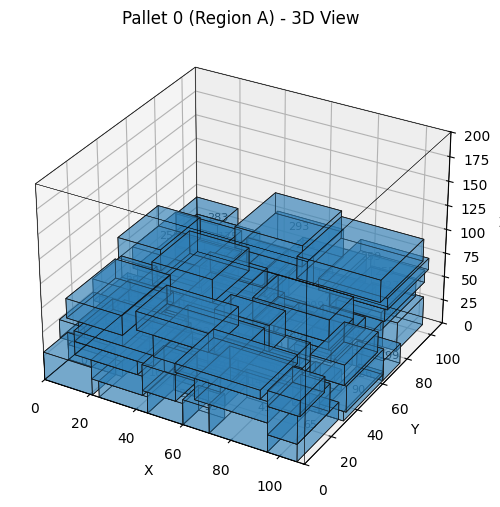

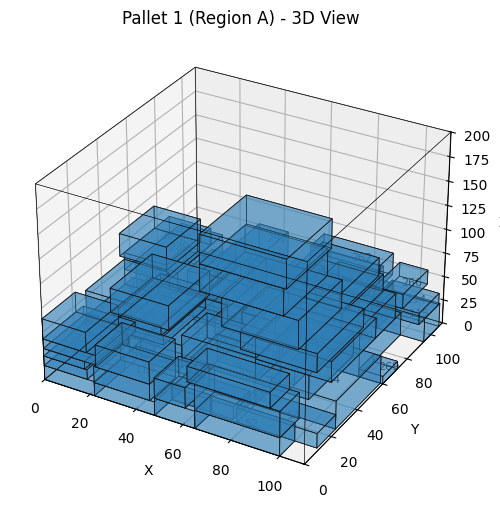

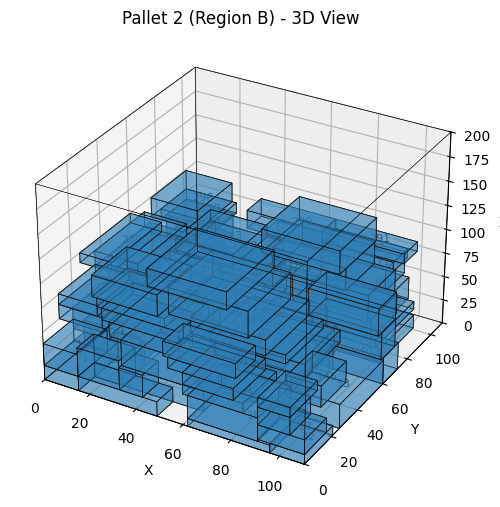

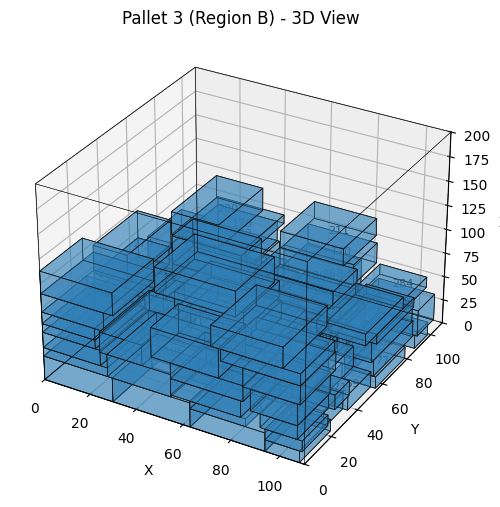

In [29]:
for pallet in result["pallets"]:
    plot_pallet_3d(pallet)

In [30]:
def pallet_items_to_df(pallet):
    rows = []
    for p in pallet.items:
        rows.append({
            "item_id": p.item.item_id,
            "region": p.item.region,
            "x": p.x1,
            "y": p.y1,
            "z": p.z1,
            "w": p.w,
            "d": p.d,
            "h": p.h,
            "weight": p.item.weight
        })
    return pd.DataFrame(rows).sort_values(["z", "x", "y"]).reset_index(drop=True)

In [31]:
pallet_items_to_df(result["pallets"][0])

,item_id,region,x,y,z,w,d,h,weight
0,0,A,0,0,0,21,16,29,5.47
1,10,A,0,16,0,24,26,16,14.62
2,26,A,0,42,0,21,23,21,8.07
3,41,A,0,65,0,29,28,11,2.95
4,68,A,0,93,0,29,15,26,5.91
...,...,...,...,...,...,...,...,...,...
63,275,A,24,38,69,26,27,24,12.22
64,285,A,11,0,73,24,33,20,6.41
65,259,A,70,66,74,35,35,23,13.75
66,293,A,41,70,81,29,31,22,2.45
